<a href="https://colab.research.google.com/github/cu24250059-pixel/Computer_vision_Lab_sheets_5thSem/blob/main/Experiment2Solution.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Experiment 2: Contrast Enhancement and Histogram-Based Image Processing using Python and OpenCV

### Name- Abhigyan Dubey
### Course & Branch- B.TECH CSE
### CUID- CU24250059
### SUBJECT - Computer Vision Lab
### SEM & Section - 5th SEM , "B"
### GitHub Repo Link -> https://github.com/cu24250059pixelComputer_vision_Lab_sheets_5thSem

#### Before running: Just put location of the img in the IMAGE_PATH, Using Python, OpenCV,NumPy, and Matplotlib

**Step 1-> Import the required libraries, including OpenCV, NumPy, and Matplotlib.**

In [5]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
from google.colab import files

**Step 2->Load a low-contrast grayscale image or convert a color image into grayscale for processing.**

In [6]:
print("Please upload an image file:")
uploaded = files.upload()
file_name = list(uploaded.keys())[0]

img_color = cv2.imread(file_name)
if img_color is None:
    raise FileNotFoundError("Image file could not be loaded.")

gray_img = cv2.cvtColor(img_color, cv2.COLOR_BGR2GRAY)

Please upload an image file:


Saving download (3).jpg to download (3) (1).jpg


**Step 3-> Display the original image and generate its histogram to analyze the distribution of pixel intensity values.**

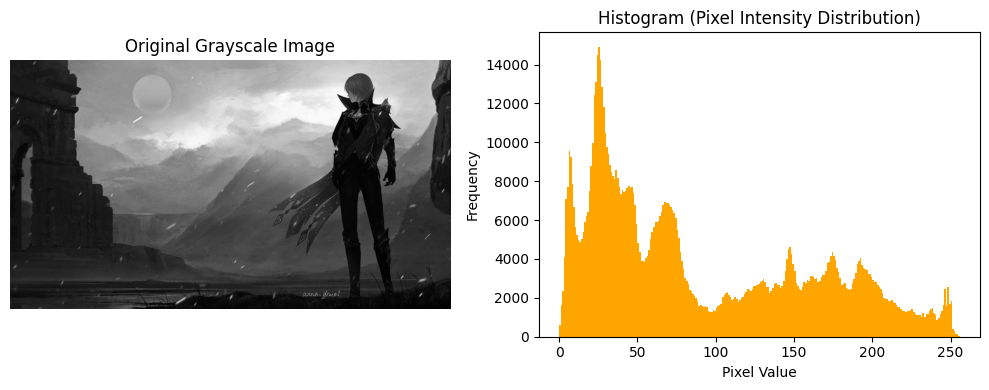

In [7]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(gray_img, cmap="gray", vmin=0, vmax=255)
plt.title("Original Grayscale Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.hist(gray_img.ravel(), bins=256, range=[0, 256], color="orange")
plt.title("Histogram (Pixel Intensity Distribution)")
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

**Step 4-> Perform contrast stretching to improve the dynamic range of pixel intensities.**

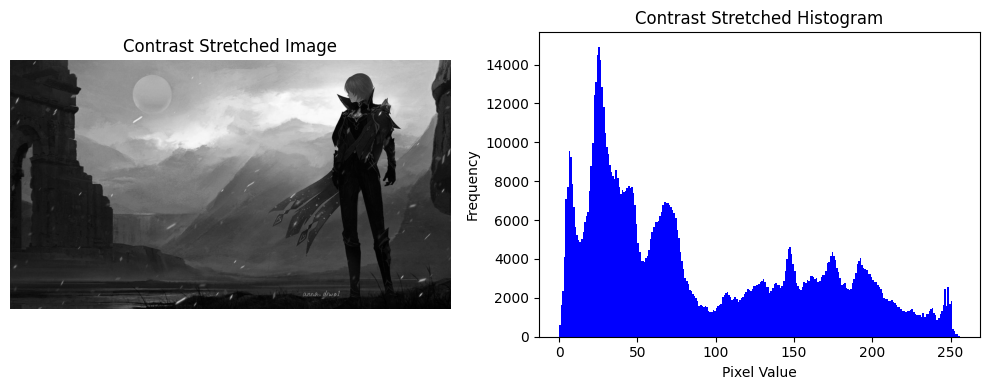

In [8]:
r_min, r_max = np.min(gray_img), np.max(gray_img)


contrast_stretched = (
    (gray_img - r_min) / (r_max - r_min) * 255.0
).astype(np.uint8)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(contrast_stretched, cmap="gray", vmin=0, vmax=255)
plt.title("Contrast Stretched Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.hist(contrast_stretched.ravel(), bins=256, range=[0, 256], color="blue")
plt.title("Contrast Stretched Histogram")
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

**Step 5->Apply Histogram Equalization using OpenCV and compare the enhanced image with the original image.**

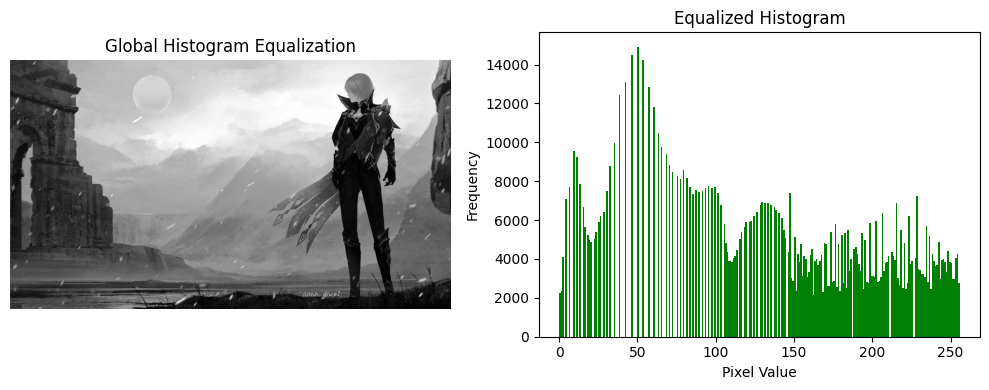

In [9]:
hist_eq = cv2.equalizeHist(gray_img)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(hist_eq, cmap="gray", vmin=0, vmax=255)
plt.title("Global Histogram Equalization")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.hist(hist_eq.ravel(), bins=256, range=[0, 256], color="green")
plt.title("Equalized Histogram")
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

**Step 6->Implement Contrast Limited Adaptive Histogram Equalization (CLAHE) and observe its performance on images with varying illumination.**

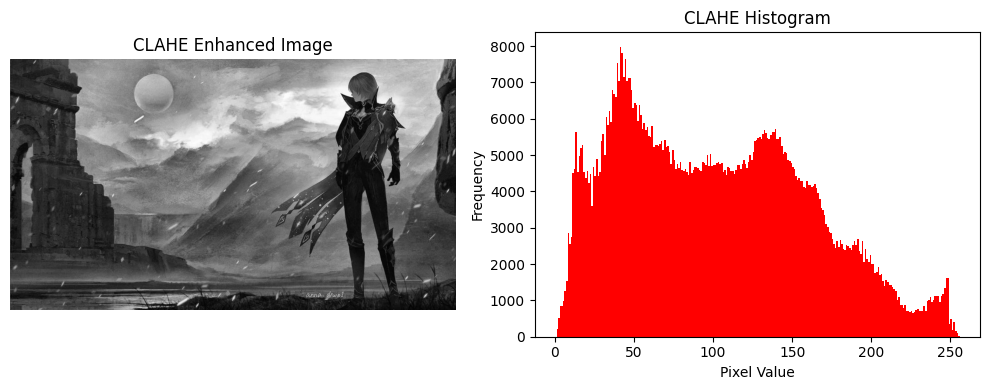

In [10]:
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
clahe_img = clahe.apply(gray_img)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(clahe_img, cmap="gray", vmin=0, vmax=255)
plt.title("CLAHE Enhanced Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.hist(clahe_img.ravel(), bins=256, range=[0, 256], color="red")
plt.title("CLAHE Histogram")
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

**Step 7->Plot and compare the histograms of the original, histogram-equalized, and CLAHE enhanced images.**

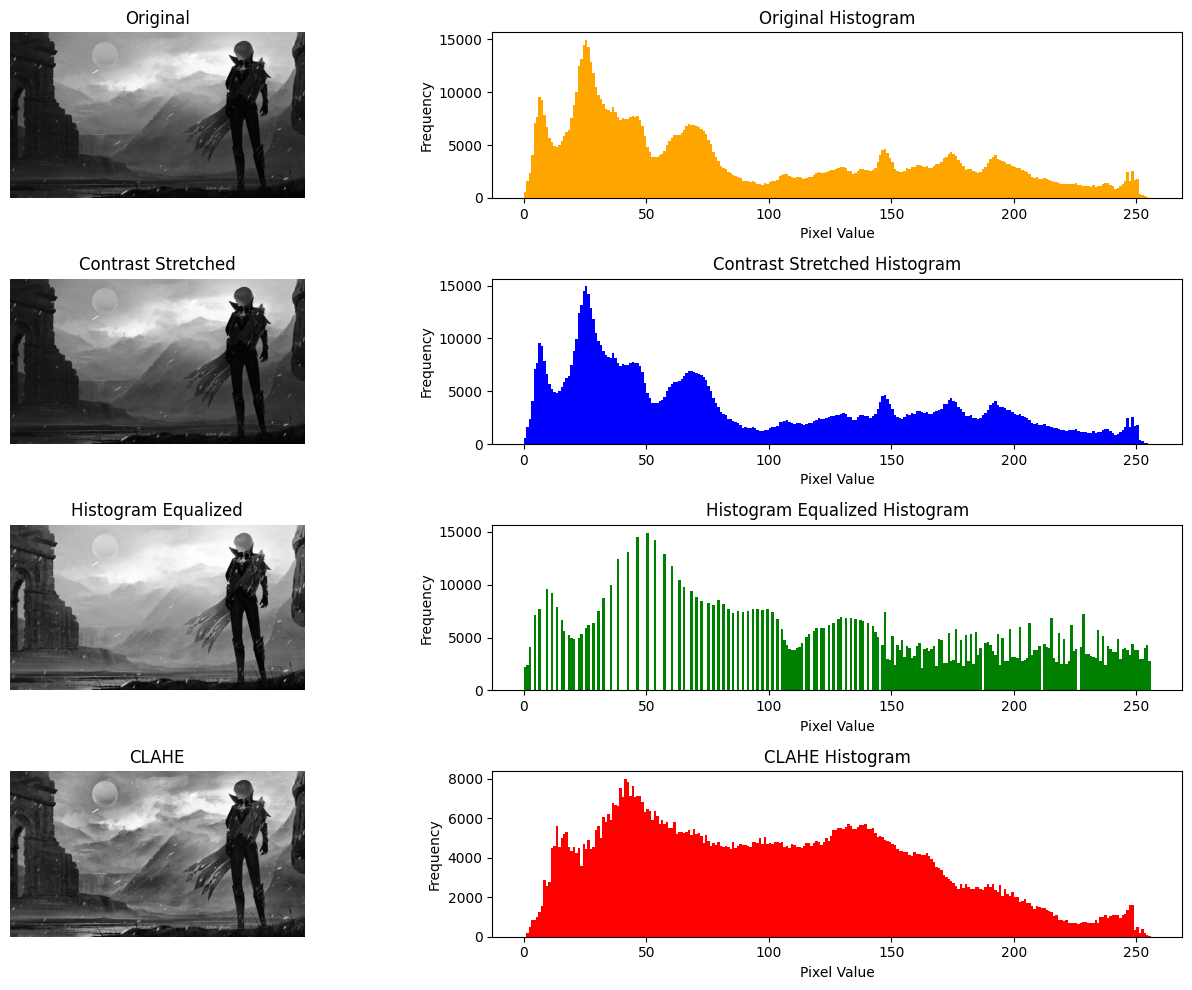

In [11]:
titles = [
    "Original",
    "Contrast Stretched",
    "Histogram Equalized",
    "CLAHE",
]
processed_images = [gray_img, contrast_stretched, hist_eq, clahe_img]
colors = ["orange", "blue", "green", "red"]

plt.figure(figsize=(14, 10))
for i in range(4):

    plt.subplot(4, 2, 2 * i + 1)
    plt.imshow(processed_images[i], cmap="gray", vmin=0, vmax=255)
    plt.title(titles[i])
    plt.axis("off")

    plt.subplot(4, 2, 2 * i + 2)
    plt.hist(
        processed_images[i].ravel(),
        bins=256,
        range=[0, 256],
        color=colors[i],
    )
    plt.title(f"{titles[i]} Histogram")
    plt.xlabel("Pixel Value")
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()